# Importing Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, f_oneway


# Loading the dataset


In [37]:
data = pd.read_excel("default_of_credit_card_clients.xls", header = 1)

In [38]:
dataset = data.drop("ID", axis = 'columns')

## Visualizing the Dataset

In [39]:
dataset

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [40]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [41]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


# Statistical Test

## PreProcessing

First we aggregate the data by default status.

In [42]:
stat_df = dataset.rename(columns={'default payment next month': 'DEFAULT'})

df_default = stat_df[stat_df['DEFAULT'] == 1]
df_non_default = stat_df[stat_df['DEFAULT'] == 0]

In [43]:
def results_to_dataframe(results_dict, sort_by='p-value'):
    """
    Converts a statistical test results dictionary into a clean DataFrame.

    Parameters:
        results_dict (dict): Dictionary of results, e.g. t_test_results
        sort_by (str): Column to sort by (default = 'p-value')

    Returns:
        pd.DataFrame: Clean, sorted table of results
    """
    df = pd.DataFrame.from_dict(results_dict, orient='index')

    # Reset index and rename for readability
    df = df.reset_index().rename(columns={'index': 'Variable'})

    # Format p-values if present
    # if 'p-value' in df.columns:
    #     df['p-value'] = df['p-value'].apply(lambda x: f"{x:.3e}")

    # Sort by p-value (if exists) or by first column
    if sort_by in df.columns:
        df = df.sort_values(by=sort_by)

    df = df.reset_index(drop=True)
    return df


## T-Test

We will choose the following variables in order to determine if they are significant in predicting defaulting:

- LIMIT_BAL
- AGE
- BILL_AMT1 to BILL_AMT6
- PAY_AMT1 to PAY_AMT6

We can determine if they are significantly different if the p-value is lower than 0.05, and strong evidence if lower than 0.001.

In [44]:
numeric_vars = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

t_test_results = {}

for col in numeric_vars:
    stat, p = ttest_ind(df_default[col], df_non_default[col], equal_var=False)
    t_test_results[col] = {'t-stat': stat, 'p-value': p}

t_test_df = results_to_dataframe(t_test_results)
t_test_df


,Variable,t-stat,p-value
0,LIMIT_BAL,-28.951588,3.364100e-178
1,PAY_AMT1,-17.512542,3.545865e-68
2,PAY_AMT2,-14.817166,1.881974e-49
3,PAY_AMT4,-12.222113,3.374781e-34
4,PAY_AMT3,-11.893461,1.780616e-32
5,PAY_AMT5,-11.245665,3.235772e-29
6,PAY_AMT6,-11.058006,2.591373e-28
7,BILL_AMT1,-3.397756,6.818918e-04
8,BILL_AMT3,-2.459066,1.394545e-02
9,BILL_AMT2,-2.446597,1.443729e-02


In [45]:
t_test_df[t_test_df['p-value'] < 0.05]

,Variable,t-stat,p-value
0,LIMIT_BAL,-28.951588,3.364100e-178
1,PAY_AMT1,-17.512542,3.545865e-68
2,PAY_AMT2,-14.817166,1.881974e-49
3,PAY_AMT4,-12.222113,3.374781e-34
4,PAY_AMT3,-11.893461,1.780616e-32
5,PAY_AMT5,-11.245665,3.235772e-29
6,PAY_AMT6,-11.058006,2.591373e-28
7,BILL_AMT1,-3.397756,6.818918e-04
8,BILL_AMT3,-2.459066,1.394545e-02
9,BILL_AMT2,-2.446597,1.443729e-02


## Chi-Square for categorical variables

Now, for the $Chi^2$ test, we will select only three categorical variables:

- SEX
- EDUCATION
- MARRIAGE

In [46]:
categorical_vars = ['SEX','EDUCATION','MARRIAGE']
chi_results = {}

for col in categorical_vars:
    contingency = pd.crosstab(stat_df[col], stat_df['DEFAULT'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results[col] = {'chi2': chi2, 'p-value': p}

chi_results_df = results_to_dataframe(chi_results)
chi_results_df


,Variable,chi2,p-value
0,EDUCATION,163.216558,1.233263e-32
1,SEX,47.708797,4.944679e-12
2,MARRIAGE,35.662396,8.825862e-08


## Chi-Square for Payment Status

Now, for the Payment status we wil use the PAY_0 to PAY_6

In [47]:
pay_vars = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
chi_pay_results = {}

for col in pay_vars:
    contingency = pd.crosstab(stat_df[col], stat_df['DEFAULT'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_pay_results[col] = {'chi2': chi2, 'p-value': p}

chi_pay_df = results_to_dataframe(chi_pay_results)
chi_pay_df


,Variable,chi2,p-value
0,PAY_0,5365.964977,0.0
1,PAY_2,3474.466790,0.0
2,PAY_3,2622.462128,0.0
3,PAY_4,2341.469945,0.0
4,PAY_5,2197.694901,0.0
5,PAY_6,1886.835309,0.0


#### Visualization For Chi-Square Test

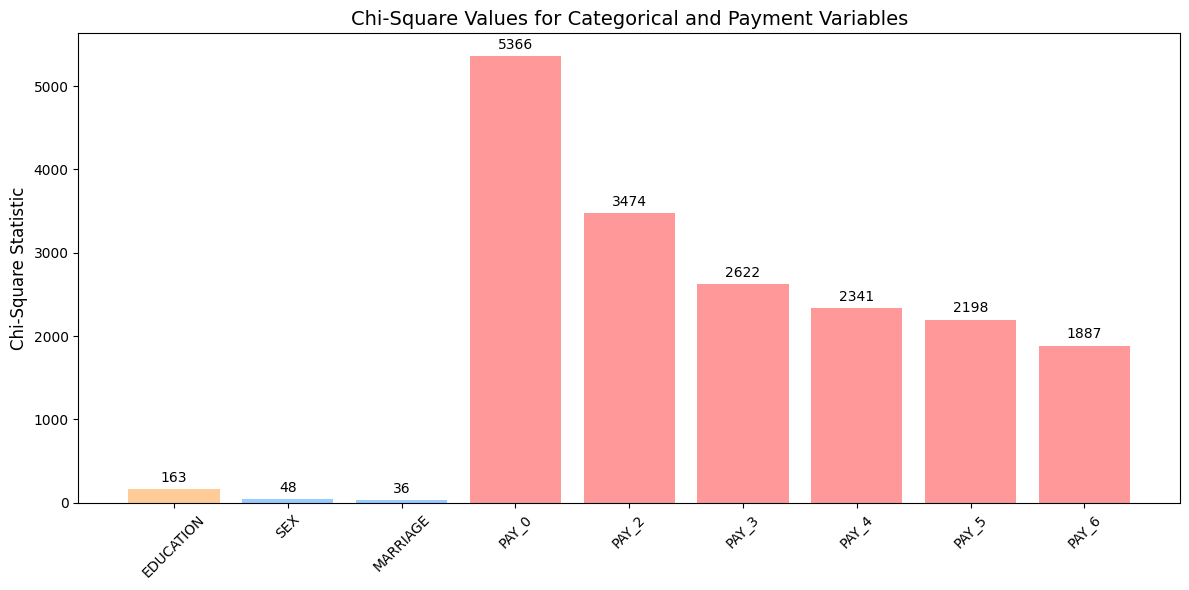

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Giả sử chi_results_df và chi_pay_df đã có 'Variable', 'Chi2', 'p-value'

# Nếu chưa có cột Variable từ index
if 'Variable' not in chi_results_df.columns:
    chi_results_df = chi_results_df.reset_index().rename(columns={'index':'Variable'})
if 'Variable' not in chi_pay_df.columns:
    chi_pay_df = chi_pay_df.reset_index().rename(columns={'index':'Variable'})

# Tạo cột Insight dựa trên Chi2
def get_insight(chi2):
    if chi2 > 1000:
        return "Very Strong"
    elif chi2 > 100:
        return "Strong"
    else:
        return "Moderate"

chi_results_df['Insight'] = chi_results_df['chi2'].apply(get_insight)
chi_pay_df['Insight'] = chi_pay_df['chi2'].apply(get_insight)

# Gộp hai bảng
df = pd.concat([chi_results_df, chi_pay_df], ignore_index=True)

# Map màu sắc
color_map = {"Very Strong": "#ff9999", "Strong": "#ffcc99", "Moderate": "#99ccff"}
colors = df['Insight'].map(color_map)

# Vẽ biểu đồ
plt.figure(figsize=(12,6))
bars = plt.bar(df['Variable'], df['chi2'], color=colors)
plt.title("Chi-Square Values for Categorical and Payment Variables", fontsize=14)
plt.ylabel("Chi-Square Statistic", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Thêm nhãn giá trị
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'{yval:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# Model Building

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

In [50]:
# Rename the target
stat_df = stat_df.rename(columns={'default payment next month': 'DEFAULT'})

# Columns we will log-transform (non-negative only)
skewed_cols_safe = [
    'LIMIT_BAL',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

# Apply log1p ONLY to safe columns
stat_df[skewed_cols_safe] = stat_df[skewed_cols_safe].apply(np.log1p)




In [51]:
# Target
y = stat_df['DEFAULT']

# RQ1 – All predictors
all_features = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

# RQ2 – Demographics only
demo_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']

# RQ2 – Payment behavior & exposure
behavior_features = [
    'LIMIT_BAL',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

# Replace +/- inf with NaN
stat_df = stat_df.replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN in any feature or target used in the model
cols_needed = all_features + ['DEFAULT']
stat_df = stat_df.dropna(subset=cols_needed)


# **Logistic Regression**

In [52]:
def run_logistic_regression(stat_df, feature_list, y, model_name):
    X = stat_df[feature_list]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression with imbalance handling
    log_reg = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs'
    )

    # Fit model
    log_reg.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = log_reg.predict(X_test_scaled)
    y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

    # Evaluation metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n======= {model_name} =======")
    print("Accuracy :", metrics['Accuracy'])
    print("Precision:", metrics['Precision'])
    print("Recall   :", metrics['Recall'])
    print("F1 Score :", metrics['F1 Score'])
    print("ROC-AUC  :", metrics['ROC-AUC'])

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Coefficients
    coef_df = pd.DataFrame({
        'Feature': feature_list,
        'Coefficient': log_reg.coef_[0]
    })
    coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

    print("\nTop coefficients (by absolute value):")
    print(coef_df[['Feature','Coefficient']].head(15))

    return log_reg, scaler, coef_df, metrics, y_test, y_pred, y_prob

In [53]:
log_reg_all, scaler_all, coef_all, metrics_all, y_test_all, y_pred_all, y_prob_all = run_logistic_regression(
    stat_df,
    all_features,
    y,
    model_name="Logistic Regression - All Features (RQ1)"
)


======= Logistic Regression - All Features (RQ1) =======
Accuracy : 0.7301111111111112
Precision: 0.42515379357484623
Recall   : 0.6248116524359618
F1 Score : 0.5059995932479154
ROC-AUC  : 0.7438645469744396

Confusion Matrix:
 [[5327 1682]
 [ 747 1244]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.76      0.81      7009
           1       0.43      0.62      0.51      1991

    accuracy                           0.73      9000
   macro avg       0.65      0.69      0.66      9000
weighted avg       0.78      0.73      0.75      9000


Top coefficients (by absolute value):
      Feature  Coefficient
5       PAY_0     0.474036
17   PAY_AMT1    -0.218092
0   LIMIT_BAL    -0.179745
11  BILL_AMT1    -0.169964
19   PAY_AMT3    -0.167439
18   PAY_AMT2    -0.159509
12  BILL_AMT2     0.156029
10      PAY_6     0.116912
7       PAY_3     0.109852
20   PAY_AMT4    -0.108904
14  BILL_AMT4     0.090104
3    MARRIAGE    -0.081848
2 

In [54]:
log_reg_demo, scaler_demo, coef_demo, metrics_demo, y_test_demo, y_pred_demo, y_prob_demo = run_logistic_regression(
    stat_df,
    demo_features,
    y,
    model_name="Logistic Regression - Demographics Only (RQ2 Model A)"
)


======= Logistic Regression - Demographics Only (RQ2 Model A) =======
Accuracy : 0.5393333333333333
Precision: 0.23954556441866087
Recall   : 0.4977398292315419
F1 Score : 0.32343342036553524
ROC-AUC  : 0.5395375279498219

Confusion Matrix:
 [[3863 3146]
 [1000  991]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.55      0.65      7009
           1       0.24      0.50      0.32      1991

    accuracy                           0.54      9000
   macro avg       0.52      0.52      0.49      9000
weighted avg       0.67      0.54      0.58      9000


Top coefficients (by absolute value):
     Feature  Coefficient
0        SEX    -0.105771
1  EDUCATION     0.058006
2   MARRIAGE    -0.050243
3        AGE    -0.022425


In [55]:
log_reg_behavior, scaler_behavior, coef_behavior, metrics_behavior, y_test_behavior, y_pred_behavior, y_prob_behavior = run_logistic_regression(
    stat_df,
    behavior_features,
    y,
    model_name="Logistic Regression - Behavior + Credit (RQ2 Model B)"
)


======= Logistic Regression - Behavior + Credit (RQ2 Model B) =======
Accuracy : 0.731
Precision: 0.4252953439888812
Recall   : 0.6147664490205926
F1 Score : 0.5027726432532348
ROC-AUC  : 0.7414105019169227

Confusion Matrix:
 [[5355 1654]
 [ 767 1224]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.76      0.82      7009
           1       0.43      0.61      0.50      1991

    accuracy                           0.73      9000
   macro avg       0.65      0.69      0.66      9000
weighted avg       0.78      0.73      0.75      9000


Top coefficients (by absolute value):
      Feature  Coefficient
1       PAY_0     0.472296
13   PAY_AMT1    -0.220210
7   BILL_AMT1    -0.178236
15   PAY_AMT3    -0.172159
14   PAY_AMT2    -0.158900
8   BILL_AMT2     0.158860
0   LIMIT_BAL    -0.145220
6       PAY_6     0.120778
3       PAY_3     0.112666
16   PAY_AMT4    -0.111820
10  BILL_AMT4     0.087392
12  BILL_AMT6     0.076400
5  

# **Random Forest**

In [56]:
def run_random_forest(stat_df, feature_list, y, model_name):
    X = stat_df[feature_list]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42
    )
    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    # Feature importance
    feat_imp = pd.DataFrame({
        'Feature': feature_list,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print(f"\n======= {model_name} =======")
    print("Metrics:", metrics)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nTop Features:\n", feat_imp.head(15))

    # Return all outputs
    return rf, feat_imp, metrics, y_test, y_pred, y_prob


In [57]:
rf_all, rf_imp_all, metrics_rf_all, y_test_rf_all, y_pred_rf_all, y_prob_rf_all = run_random_forest(
    stat_df,
    all_features,
    y,
    model_name="Random Forest - All Features (Alternative Model)"
)



======= Random Forest - All Features (Alternative Model) =======
Metrics: {'Accuracy': 0.8125555555555556, 'Precision': 0.644212523719165, 'Recall': 0.341034655951783, 'F1 Score': 0.4459770114942529, 'ROC-AUC': 0.7628737579917162}

Confusion Matrix:
 [[6634  375]
 [1312  679]]

Top Features:
       Feature  Importance
5       PAY_0    0.097351
0   LIMIT_BAL    0.063511
4         AGE    0.062198
11  BILL_AMT1    0.060965
12  BILL_AMT2    0.052835
17   PAY_AMT1    0.052821
18   PAY_AMT2    0.051464
13  BILL_AMT3    0.050316
19   PAY_AMT3    0.049108
15  BILL_AMT5    0.048985
14  BILL_AMT4    0.048622
16  BILL_AMT6    0.048340
22   PAY_AMT6    0.046896
20   PAY_AMT4    0.045013
21   PAY_AMT5    0.043830


In [58]:
rf_behavior, rf_imp_behavior, metrics_rf_behavior, y_test_rf_behavior, y_pred_rf_behavior, y_prob_rf_behavior = run_random_forest(
    stat_df,
    behavior_features,
    y,
    model_name="Random Forest - Behavior Feature (Alternative Model)"
)



======= Random Forest - Behavior Feature (Alternative Model) =======
Metrics: {'Accuracy': 0.8084444444444444, 'Precision': 0.6120906801007556, 'Recall': 0.3661476644902059, 'F1 Score': 0.4582023884349466, 'ROC-AUC': 0.7554144886115068}

Confusion Matrix:
 [[6547  462]
 [1262  729]]

Top Features:
       Feature  Importance
1       PAY_0    0.100859
7   BILL_AMT1    0.073644
0   LIMIT_BAL    0.068714
8   BILL_AMT2    0.061867
14   PAY_AMT2    0.058946
13   PAY_AMT1    0.058660
9   BILL_AMT3    0.057860
12  BILL_AMT6    0.056034
11  BILL_AMT5    0.055837
10  BILL_AMT4    0.055682
15   PAY_AMT3    0.055523
18   PAY_AMT6    0.054131
16   PAY_AMT4    0.050850
17   PAY_AMT5    0.049619
2       PAY_2    0.046928


### Compare Models

In [59]:
performance_metrics = {
    'LG All Features': metrics_all,
    'LG Demographics Only': metrics_demo,
    'LG Behavior + Credit': metrics_behavior,
    'Random Forest - All Features': metrics_rf_all,
    'Random Forest - Behavior Features': metrics_rf_behavior
}


In [60]:
performance_df = pd.DataFrame.from_dict(performance_metrics, orient='index')
performance_df.index.name = 'Model'
print(performance_df)

                                   Accuracy  Precision    Recall  F1 Score  \
Model                                                                        
LG All Features                    0.730111   0.425154  0.624812  0.506000   
LG Demographics Only               0.539333   0.239546  0.497740  0.323433   
LG Behavior + Credit               0.731000   0.425295  0.614766  0.502773   
Random Forest - All Features       0.812556   0.644213  0.341035  0.445977   
Random Forest - Behavior Features  0.808444   0.612091  0.366148  0.458202   

                                    ROC-AUC  
Model                                        
LG All Features                    0.743865  
LG Demographics Only               0.539538  
LG Behavior + Credit               0.741411  
Random Forest - All Features       0.762874  
Random Forest - Behavior Features  0.755414  


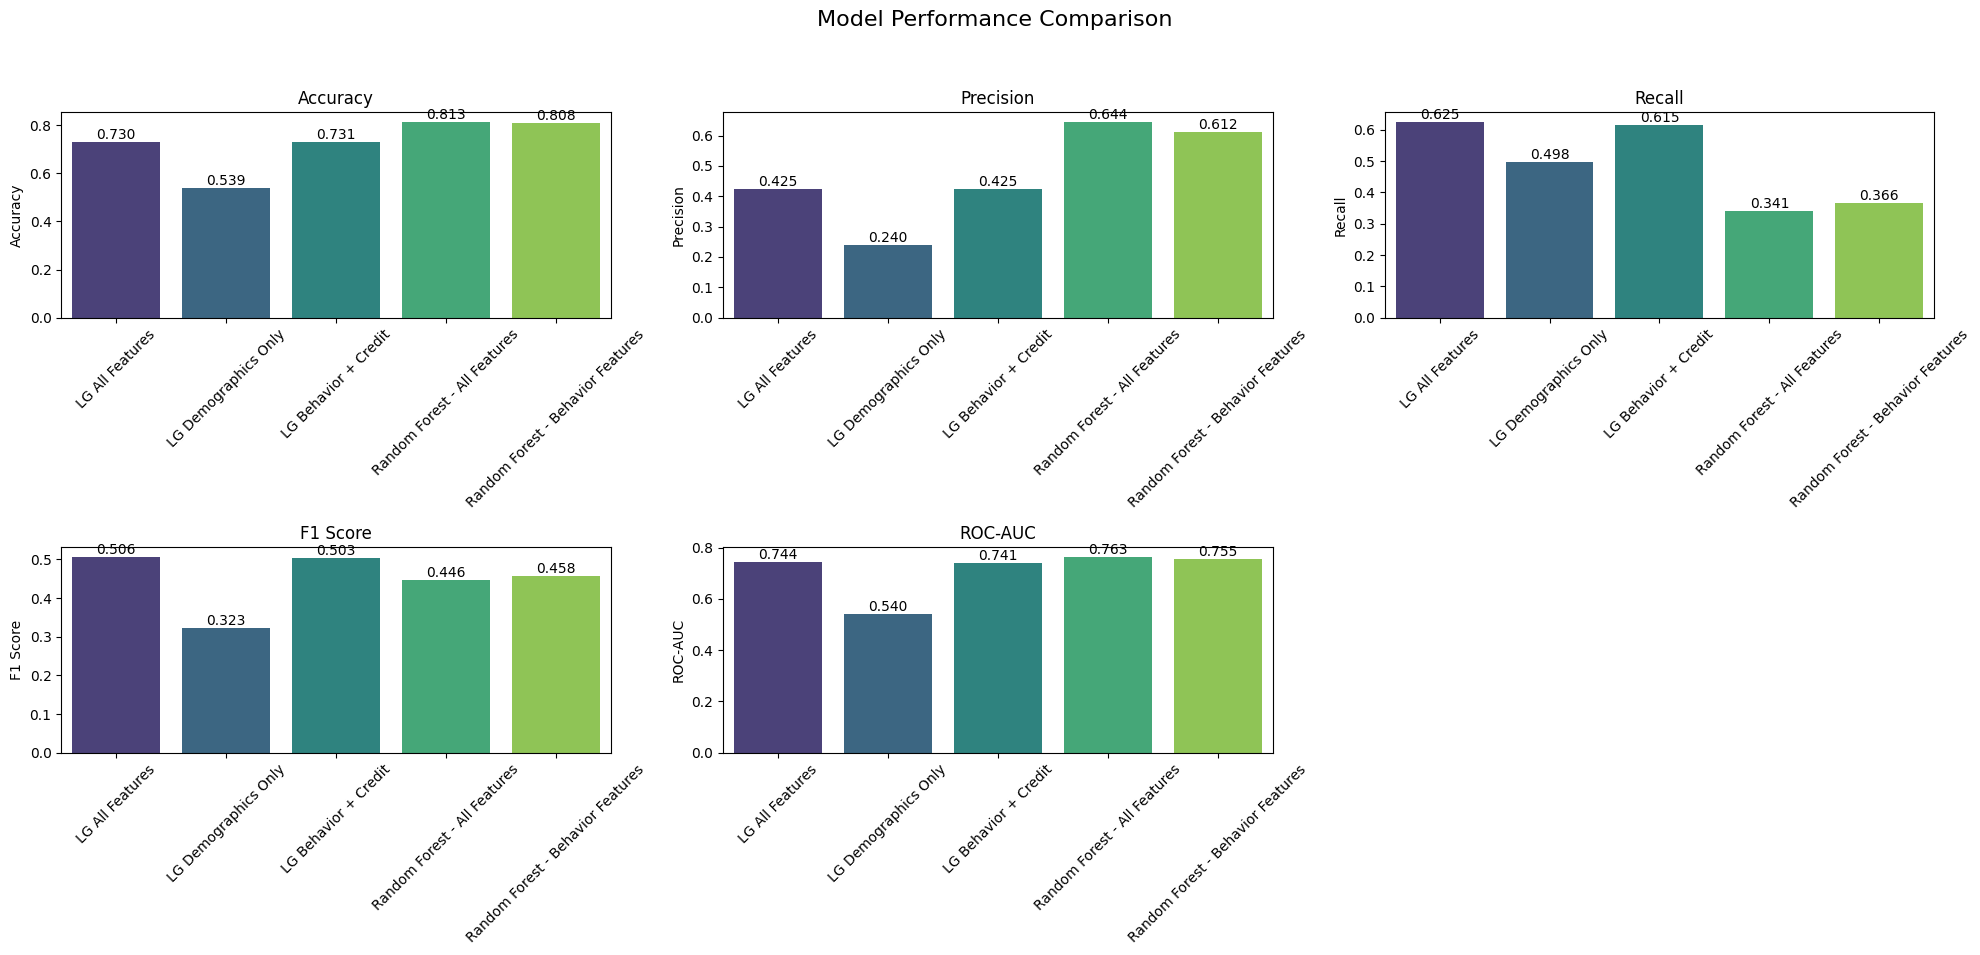

In [61]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10)) # Change to 2 rows, 3 columns
fig.suptitle('Model Performance Comparison', fontsize=16)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors = sns.color_palette('viridis', n_colors=len(performance_df))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x=performance_df.index, y=metric, data=performance_df, ax=axes[i], hue=performance_df.index, palette=colors, legend=False)
    axes[i].set_title(metric)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

    # Add value labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f')

# Remove any unused subplots if the number of metrics is less than nrows*ncols
for j in range(len(metrics), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Confusion matrix plot

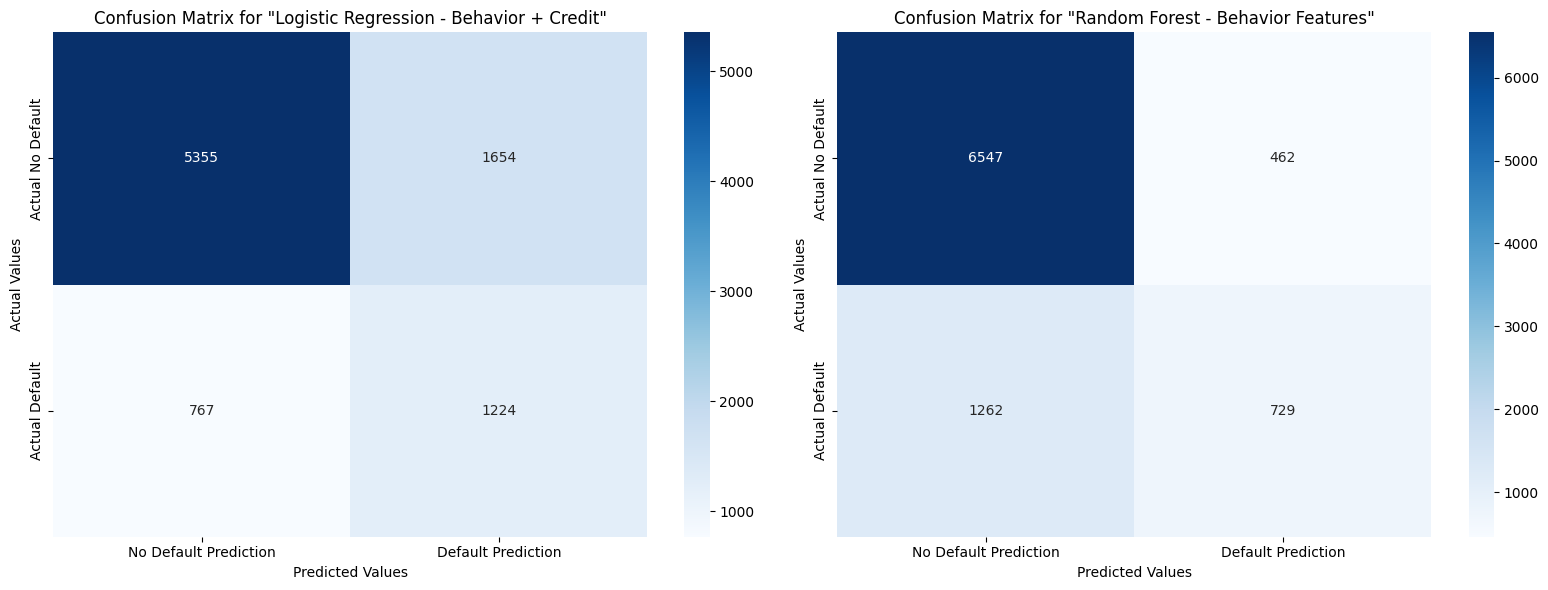

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


models = {
    "Logistic Regression - Behavior + Credit": (y_test_behavior, y_pred_behavior),
    "Random Forest - Behavior Features": (y_test_rf_behavior, y_pred_rf_behavior)
}


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, (y_test, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default Prediction', 'Default Prediction'],
                yticklabels=['Actual No Default', 'Actual Default'],
                ax=ax)
    ax.set_title(f'Confusion Matrix for "{model_name}"')
    ax.set_ylabel('Actual Values')
    ax.set_xlabel('Predicted Values')

plt.tight_layout()
plt.show()


### ROC AUC Curve

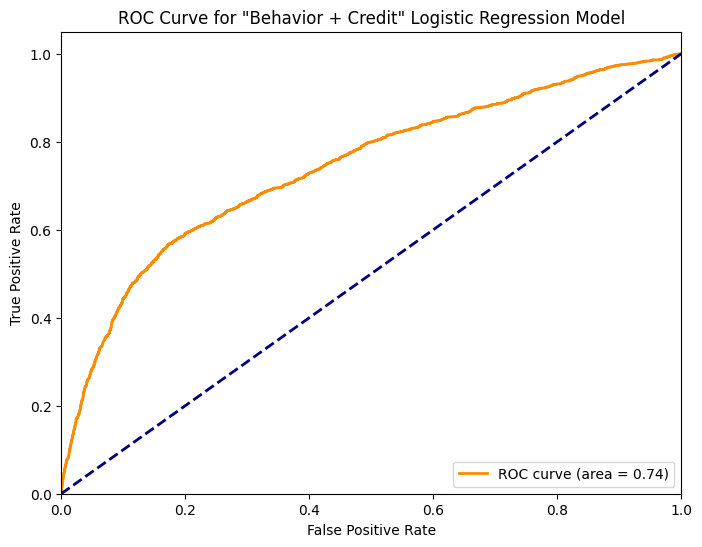

In [63]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test_behavior, y_prob_behavior)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for "Behavior + Credit" Logistic Regression Model')
plt.legend(loc="lower right")
plt.show()

### Feature importance

In [64]:
def get_top_coefficients(coef_df, n=10):
    """
    Returns the top N coefficients by absolute value from a coefficient DataFrame.
    """
    return coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(n)

# Get top 10 coefficients for each model
top_coef_all = get_top_coefficients(coef_all, n=10)
top_coef_demo = get_top_coefficients(coef_demo, n=10) # n=4 for demo as it only has 4 features
top_coef_behavior = get_top_coefficients(coef_behavior, n=10)


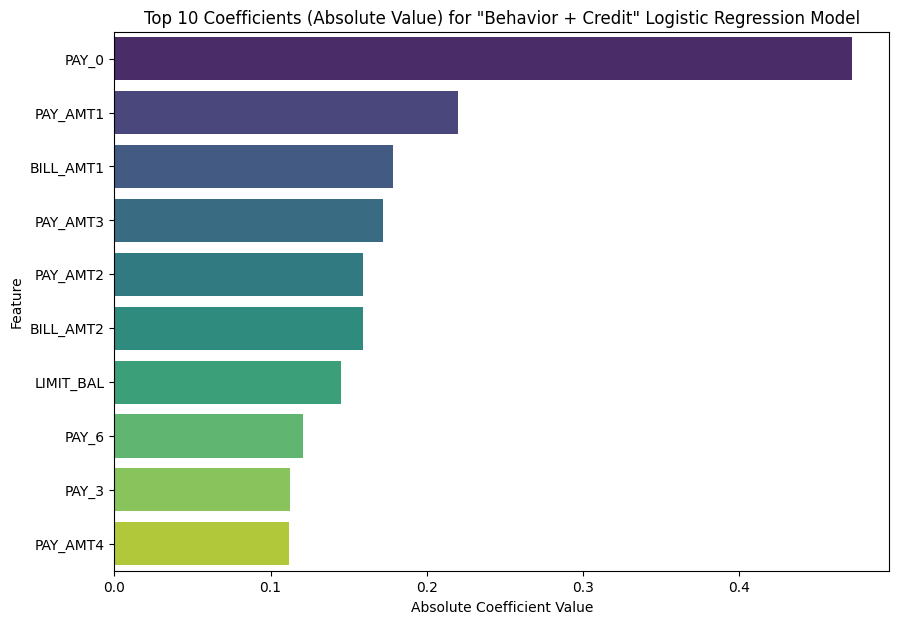

In [65]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Abs_Coefficient', y='Feature', data= top_coef_behavior, hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Coefficients (Absolute Value) for "Behavior + Credit" Logistic Regression Model')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()